In [4]:
# importando bibliotecas
import pandas as pd # manipulação e analise de dados
import matplotlib.pyplot as plt # visualização de dados
import seaborn as sns # visualização de dados

# pip install pandas matplotlib seaborn



- *Carregando dados*

In [5]:
# Filtrar colunas
colunas_desejadas = ["Player", "Pos", "Squad", "Comp", "Gls", "Ast", "G+A", "Saves", "TklW", "Int"]

# Ler dados de arquivo CSV
df = pd.read_csv(r"data\players_data_light-2026_2027.csv", usecols=colunas_desejadas)

# Criar coluna de desarmes + interceptações
df["Tkl+Int"] = df["TklW"] + df["Int"]

# Visualizar dados
df

,Player,Pos,Squad,Comp,Gls,Ast,G+A,TklW,Int,Saves,Tkl+Int
0,Brenden Aaronson,MF,Leeds United,eng Premier League,0,0,0,2,0,NaN,2
1,Haitam Abaida,FW,Málaga,es La Liga,0,0,0,0,0,NaN,0
2,James Abankwah,DF,Udinese,it Serie A,0,0,0,5,1,NaN,6
3,Keyliane Abdallah,FW,Marseille,fr Ligue 1,1,0,1,0,0,NaN,0
4,Hamza Abdelkarim,FW,Barcelona,es La Liga,0,0,0,0,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
2029,Martín Zubimendi,MF,Arsenal,eng Premier League,0,0,0,2,3,NaN,5
2030,Adam Zulevic,FW,Genoa,it Serie A,0,0,0,0,0,NaN,0
2031,Martin Ødegaard,MF,Arsenal,eng Premier League,2,0,2,4,1,NaN,5
2032,Leo Østigård,DF,Genoa,it Serie A,0,0,0,5,4,NaN,9


- *Exploração Inicial*

In [6]:
# Quantidade de jogadores por liga
print("\nJogadores por liga:")
print(df['Comp'].value_counts())

# Quantidade de jogadores por posição'
print("\nJogadores por posição:")
print(df['Pos'].value_counts())


Jogadores por liga:
Comp
es La Liga            446
it Serie A            437
eng Premier League    410
fr Ligue 1            383
de Bundesliga         358
Name: count, dtype: int64

Jogadores por posição:
Pos
MF       783
DF       582
FW       297
FW,MF    121
GK       115
DF,MF     64
MF,FW     40
MF,DF     27
DF,FW      5
Name: count, dtype: int64


In [7]:
# Exemplos manipulação strings
S = "DF,MF"
# s.split(",")  # ['DF', 'MF']
S.split(",")[0]

'DF'

In [8]:
# Ajustando posição principal do jogador
df['Pos'] = df['Pos'].apply(lambda x: x.split(",")[0] if isinstance(x, str) else x)

print("\nDistribuição de jogadores por posição após ajuste:")
print(df['Pos'].value_counts())


Distribuição de jogadores por posição após ajuste:
Pos
MF    850
DF    651
FW    418
GK    115
Name: count, dtype: int64


- *Estatísticaas ofensivas*

                         Player           Squad        Comp  Gls
1993               Lamine Yamal       Barcelona  es La Liga    6
310              Sergio Camello  Rayo Vallecano  es La Liga    6
1213              Kylian Mbappé     Real Madrid  es La Liga    6
1554                   Raphinha       Barcelona  es La Liga    6
618           Roberto Férnandez        Espanyol  es La Liga    5
2006              Yassir Zabiri     Racing Sant  es La Liga    5
111   Pierre-Emerick Aubameyang   Dep. A Coruña  es La Liga    5
1141              Donyell Malen            Roma  it Serie A    5
533              Kamory Doumbia           Brest  fr Ligue 1    4
733                Amine Gouiri       Marseille  fr Ligue 1    4


C:\Users\Daniel\AppData\Local\Temp\ipykernel_9300\3225832768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gls', y='Player', data=top_scorers, palette='viridis')


Text(0.5, 1.0, 'Top 10 Artilheiros da Temporada 2026/2027')

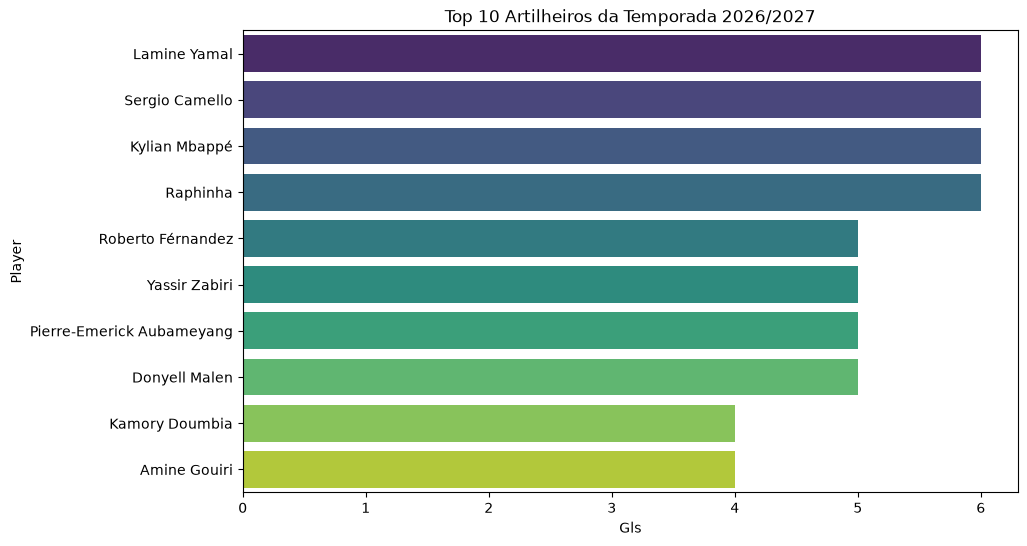

In [9]:
# Top 10 artilheros - Métrica = Gols (Gls)
top_scorers = df.sort_values(by='Gls', ascending=False).head(10)[['Player', 'Squad', 'Comp', 'Gls']]

print(top_scorers)

# Visualizar dados (grafico de barras horizontal)
plt.figure(figsize=(10, 6))
sns.barplot(x='Gls', y='Player', data=top_scorers, palette='viridis')
plt.title('Top 10 Artilheiros da Temporada 2026/2027')



                    Player           Squad                Comp  Ast
727         Anthony Gordon       Barcelona          es La Liga    4
547           Paulo Dybala            Roma          it Serie A    4
661             Cody Gakpo       Liverpool  eng Premier League    3
915        Vinicius Júnior     Real Madrid          es La Liga    3
586              Evanilson     Bournemouth  eng Premier League    3
334  Cristian Cásseres Jr.        Toulouse          fr Ligue 1    3
907             João Pedro         Chelsea  eng Premier League    3
929          Daichi Kamada  Crystal Palace  eng Premier League    3
706        Matthias Ginter        Freiburg       de Bundesliga    3
941         Panos Katseris         Lorient          fr Ligue 1    3


C:\Users\Daniel\AppData\Local\Temp\ipykernel_9300\2415284974.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ast', y='Player', data=top_assistants, palette='magma')


Text(0.5, 1.0, 'Top 10 Assistentes da Temporada 2026/2027')

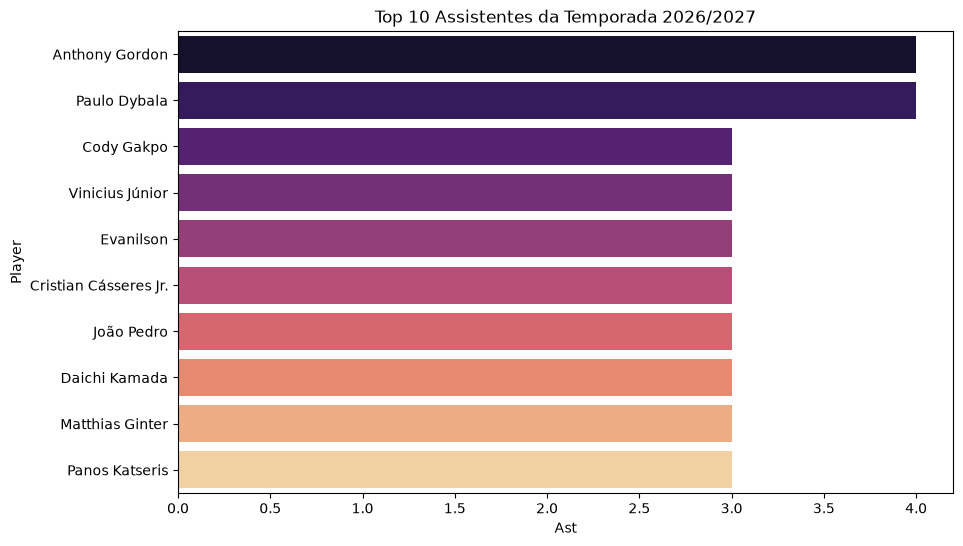

In [10]:
# Top 10 assistentes - Métrica = Assistências (Ast)
top_assistants = df.sort_values(by='Ast', ascending=False).head(10)[['Player', 'Squad', 'Comp', 'Ast']]

print(top_assistants)

# Visualizar dados (grafico de barras horizontal)
plt.figure(figsize=(10, 6))
sns.barplot(x='Ast', y='Player', data=top_assistants, palette='magma')
plt.title('Top 10 Assistentes da Temporada 2026/2027')

                         Player           Squad                Comp  G+A
1554                   Raphinha       Barcelona          es La Liga    9
1213              Kylian Mbappé     Real Madrid          es La Liga    7
111   Pierre-Emerick Aubameyang   Dep. A Coruña          es La Liga    7
310              Sergio Camello  Rayo Vallecano          es La Liga    7
1094               Fermin López       Barcelona          es La Liga    6
1163                    Mariano          Alavés          es La Liga    6
907                  João Pedro         Chelsea  eng Premier League    6
1993               Lamine Yamal       Barcelona          es La Liga    6
618           Roberto Férnandez        Espanyol          es La Liga    5
533              Kamory Doumbia           Brest          fr Ligue 1    5


C:\Users\Daniel\AppData\Local\Temp\ipykernel_9300\779346136.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='G+A', y='Player', data=top_offensive, palette='coolwarm')


Text(0.5, 1.0, 'Top 10 Jogadores Ofensivos da Temporada 2026/2027')

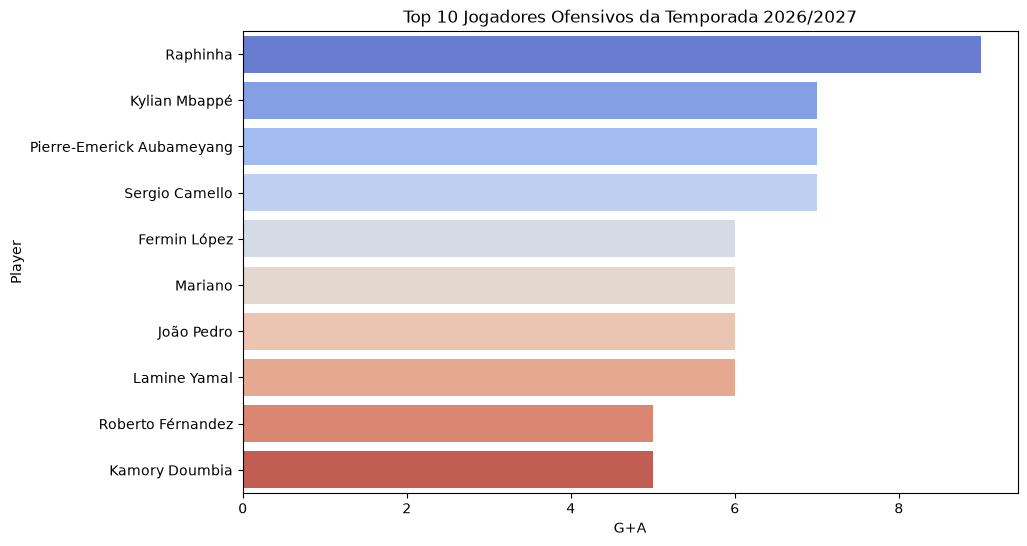

In [11]:
# Top ofensivos -   Métrica = Gols + Assistências (G+A)
top_offensive = df.sort_values(by='G+A', ascending=False).head(10)[['Player', 'Squad', 'Comp', 'G+A']]

print(top_offensive)

# Visualizar dados (grafico de barras horizontal)
plt.figure(figsize=(10, 6))
sns.barplot(x='G+A', y='Player', data=top_offensive, palette='coolwarm')
plt.title('Top 10 Jogadores Ofensivos da Temporada 2026/2027')

- *Quais as melhores ligas ?*

In [12]:
# Liga com maior qualidade DEFENSIVA
df.groupby('Comp')['Saves'].mean().sort_values(ascending=False)

Comp
es La Liga            13.304348
fr Ligue 1            10.565217
it Serie A             9.840000
eng Premier League     9.695652
de Bundesliga          8.904762
Name: Saves, dtype: float64

In [13]:
# Liga com maior qualidade OFENSIVA
df.groupby('Comp')['G+A'].mean().sort_values(ascending=False)

Comp
es La Liga            0.544843
de Bundesliga         0.497207
fr Ligue 1            0.438642
it Serie A            0.434783
eng Premier League    0.434146
Name: G+A, dtype: float64

                  Player          Squad           Comp  Saves
596    Wladimiro Falcone          Lecce     it Serie A   26.0
29    Julen Agirrezabala    Racing Sant     es La Liga   23.0
1093       Anthony Lopes         Angers     fr Ligue 1   23.0
937         Loris Karius     Schalke 04  de Bundesliga   22.0
327    Marco Carnesecchi       Atalanta     it Serie A   22.0
513      Marko Dmitrović       Espanyol     es La Liga   19.0
829      Alfonso Herrero         Málaga     es La Liga   19.0
1300        Lionel Mpasi       Le Havre     fr Ligue 1   19.0
1572         Álex Remiro  Real Sociedad     es La Liga   19.0
1365      Moritz Nicolas       Gladbach  de Bundesliga   18.0


C:\Users\Daniel\AppData\Local\Temp\ipykernel_9300\544998541.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Saves', y='Player', data=top_goleiros, palette='Blues')


Text(0.5, 1.0, 'Top 10 Goleiros da Temporada 2026/2027')

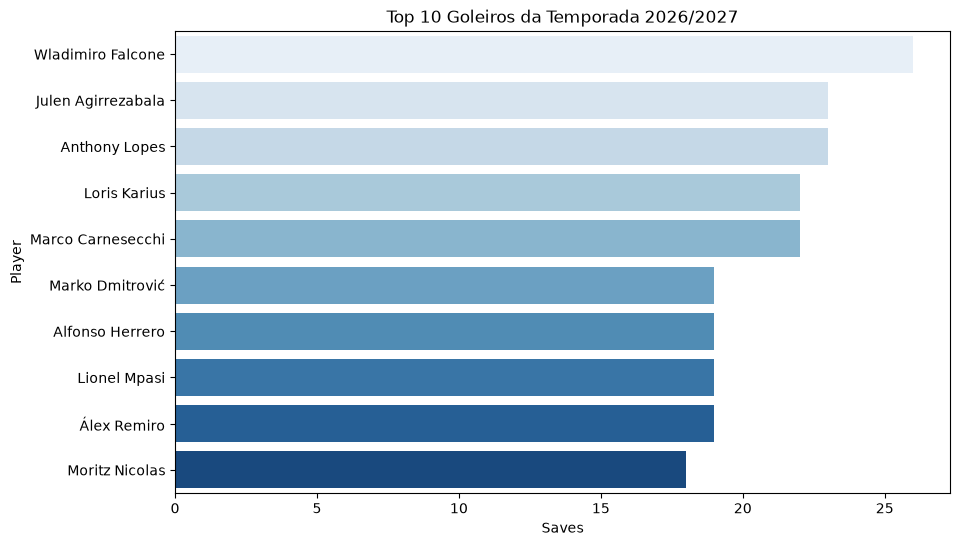

In [14]:
# Top ofensivos
top_goleiros = df.sort_values(by='Saves', ascending=False).head(10)[['Player', 'Squad', 'Comp', 'Saves']]

print(top_goleiros)

# Visualizar dados (grafico de barras horizontal)
plt.figure(figsize=(10, 6))
sns.barplot(x='Saves', y='Player', data=top_goleiros, palette='Blues')
plt.title('Top 10 Goleiros da Temporada 2026/2027')

- *Qual o melhor time da temporada?*

In [15]:
# Filtrando jogadores por posição
goleiros = df[df['Pos'] == 'GK']
defensores = df[df['Pos'] == 'DF']
meio_campistas = df[df['Pos'] == 'MF']
atacantes = df[df['Pos'] == 'FW']

In [16]:
# Top 1 goleiro (saves)
# ["Player", "Pos", "Squad", "Comp"]
melhor_goleiro = goleiros.sort_values(by='Saves', ascending=False).head(1)[["Player", "Pos", "Squad", "Comp"]]
display(melhor_goleiro)

# Top 3 defensores (Tkl+Int)
melhores_defensores = defensores.sort_values(by='Tkl+Int', ascending=False).head(3)[["Player", "Pos", "Squad", "Comp"]]
display(melhores_defensores)

# Top 5 meio-campistas (KP)
melhores_meio_campistas = meio_campistas.sort_values(by='Ast', ascending=False).head(5)[["Player", "Pos", "Squad", "Comp"]]
display(melhores_meio_campistas)

# Top 2 atacantes (G+A)
melhores_atacantes = atacantes.sort_values(by='G+A', ascending=False).head(2)[["Player", "Pos", "Squad", "Comp"]]
display(melhores_atacantes)


,Player,Pos,Squad,Comp
596,Wladimiro Falcone,GK,Lecce,it Serie A


,Player,Pos,Squad,Comp
93,Jon Aramburu,DF,Real Sociedad,es La Liga
1678,Manu Sánchez,DF,Levante,es La Liga
820,Mario Hermoso,DF,Roma,it Serie A


,Player,Pos,Squad,Comp
547,Paulo Dybala,MF,Roma,it Serie A
334,Cristian Cásseres Jr.,MF,Toulouse,fr Ligue 1
929,Daichi Kamada,MF,Crystal Palace,eng Premier League
661,Cody Gakpo,MF,Liverpool,eng Premier League
821,Javier Hernández,MF,Espanyol,es La Liga


,Player,Pos,Squad,Comp
1554,Raphinha,FW,Barcelona,es La Liga
1213,Kylian Mbappé,FW,Real Madrid,es La Liga


In [21]:
# Concatenar dataframes
dream_team = pd.concat([melhor_goleiro, melhores_defensores, melhores_meio_campistas, melhores_atacantes])

# Visualizar dream team
print("\nDream Team da Temporada 2026/2027:")
print(dream_team)


Dream Team da Temporada 2026/2027:
                     Player Pos           Squad                Comp
596       Wladimiro Falcone  GK           Lecce          it Serie A
93             Jon Aramburu  DF   Real Sociedad          es La Liga
1678           Manu Sánchez  DF         Levante          es La Liga
820           Mario Hermoso  DF            Roma          it Serie A
547            Paulo Dybala  MF            Roma          it Serie A
334   Cristian Cásseres Jr.  MF        Toulouse          fr Ligue 1
929           Daichi Kamada  MF  Crystal Palace  eng Premier League
661              Cody Gakpo  MF       Liverpool  eng Premier League
821        Javier Hernández  MF        Espanyol          es La Liga
1554               Raphinha  FW       Barcelona          es La Liga
1213          Kylian Mbappé  FW     Real Madrid          es La Liga


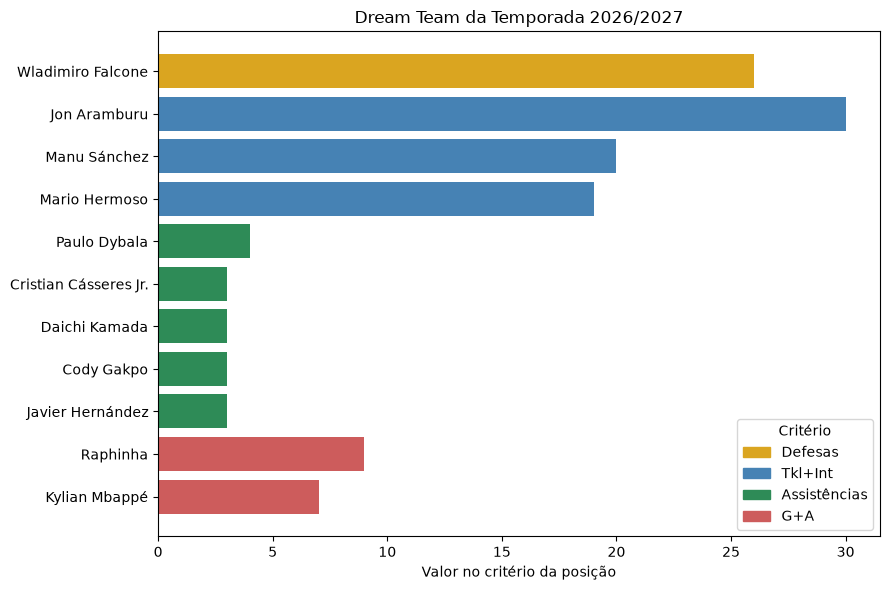

In [22]:
import matplotlib.pyplot as plt

# Monta uma coluna única com o valor do critério de cada jogador
dream_team_plot = dream_team.copy()
dream_team_plot['Valor'] = [
    melhor_goleiro['Player'].map(lambda x: goleiros.loc[goleiros['Player']==x, 'Saves'].values[0]).values[0],
    *defensores.set_index('Player').loc[melhores_defensores['Player'], 'Tkl+Int'].values,
    *meio_campistas.set_index('Player').loc[melhores_meio_campistas['Player'], 'Ast'].values,
    *atacantes.set_index('Player').loc[melhores_atacantes['Player'], 'G+A'].values,
]
dream_team_plot['Critério'] = ['Defesas']*1 + ['Tkl+Int']*3 + ['Assistências']*5 + ['G+A']*2

cores = {'Defesas': 'goldenrod', 'Tkl+Int': 'steelblue', 'Assistências': 'seagreen', 'G+A': 'indianred'}

plt.figure(figsize=(9,6))
plt.barh(dream_team_plot['Player'], dream_team_plot['Valor'],
         color=[cores[c] for c in dream_team_plot['Critério']])
plt.xlabel('Valor no critério da posição')
plt.title('Dream Team da Temporada 2026/2027')
plt.gca().invert_yaxis()

# Legenda manual por posição
handles = [plt.Rectangle((0,0),1,1, color=cor) for cor in cores.values()]
plt.legend(handles, cores.keys(), title='Critério', loc='lower right')

plt.tight_layout()
plt.show()

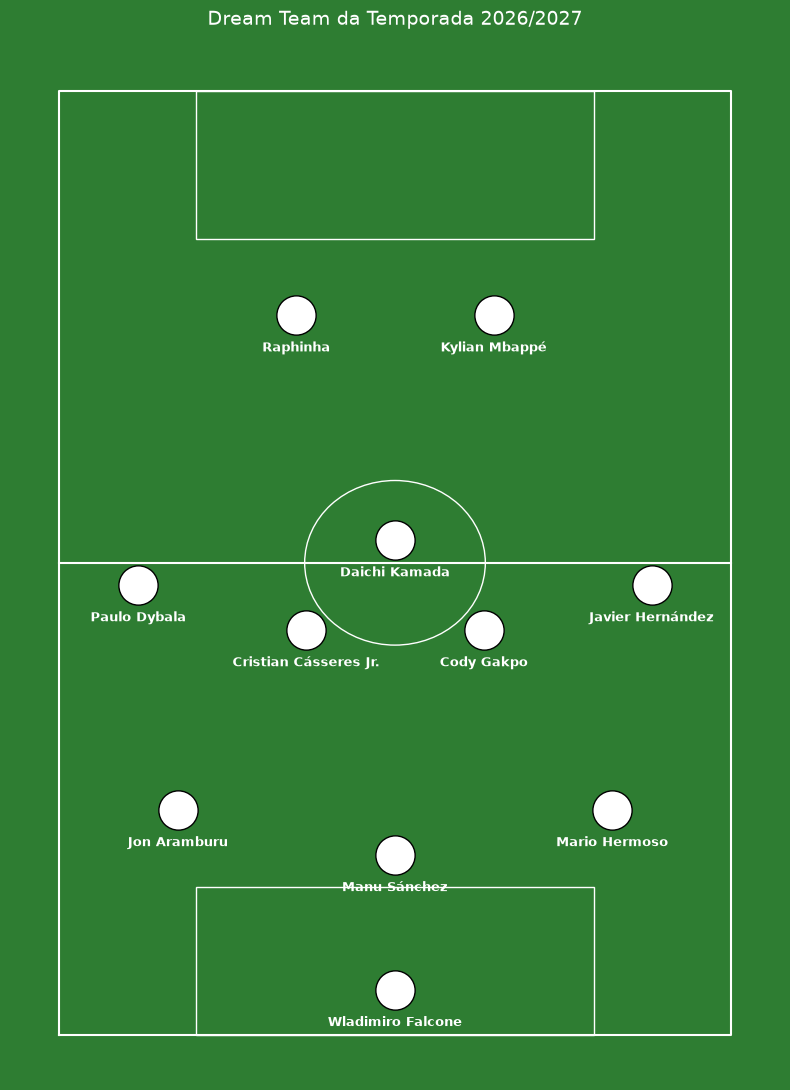

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 11))

# Desenha o campo (fundo verde, linhas brancas)
ax.set_facecolor('#2e7d32')
fig.patch.set_facecolor('#2e7d32')
ax.plot([0,0,68,68,0],[0,105,105,0,0], color='white')
ax.plot([0,68],[52.5,52.5], color='white')
ax.add_patch(plt.Circle((34,52.5), 9.15, color='white', fill=False))
ax.add_patch(patches.Rectangle((13.84,0), 40.32, 16.5, edgecolor='white', facecolor='none'))
ax.add_patch(patches.Rectangle((13.84,88.5), 40.32, 16.5, edgecolor='white', facecolor='none'))

# Posições (x, y) para formação 3-5-2
posicoes = {
    'GK': [(34, 5)],
    'DF': [(12, 25), (34, 20), (56, 25)],
    'MF': [(8, 50), (25, 45), (34, 55), (43, 45), (60, 50)],
    'FW': [(24, 80), (44, 80)],
}

jogadores = {
    'GK': list(melhor_goleiro['Player']),
    'DF': list(melhores_defensores['Player']),
    'MF': list(melhores_meio_campistas['Player']),
    'FW': list(melhores_atacantes['Player']),
}

for pos, coords in posicoes.items():
    for (x, y), nome in zip(coords, jogadores[pos]):
        ax.scatter(x, y, s=800, color='white', edgecolor='black', zorder=3)
        ax.text(x, y-4, nome, ha='center', fontsize=9, color='white',
                 fontweight='bold', zorder=4)

ax.set_xlim(-5, 73)
ax.set_ylim(-5, 110)
ax.axis('off')
ax.set_title('Dream Team da Temporada 2026/2027', color='white', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Visualização em campo

Representação tática do Dream Team, com os 11 jogadores posicionados por função (formação 3-5-2). Complementa o gráfico de barras: enquanto o gráfico mostra a diferença de desempenho entre os jogadores, essa visualização dá a noção espacial de como o time ficaria em campo.